In [17]:
from google.colab import files

# The World Development Indicators(22_6_26).zip file is already present in the Colab environment.
# Directly assign the path to 'uploaded' to simulate a file upload.
uploaded = {'/content/World Development Indicators(22_6_26).zip': None}

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import glob

In [24]:
import os

# Explicitly define the correct zip file path to ensure consistency
correct_zip_file_path = '/content/World Development Indicators(22_6_26).zip'
extracted_dir_name = "wdi_files"

# Ensure the extraction directory exists and extract the zip file
if not os.path.exists(extracted_dir_name):
    os.makedirs(extracted_dir_name)

try:
    with zipfile.ZipFile(correct_zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_dir_name)
    print(f"Successfully extracted {correct_zip_file_path} to {extracted_dir_name}")
except FileNotFoundError:
    print(f"Error: Zip file not found at {correct_zip_file_path}. Please ensure it is uploaded and available.")
    raise # Re-raise the error to halt execution
except Exception as e:
    print(f"Error during zip file extraction: {e}")
    raise # Re-raise other extraction errors

# Find the actual data CSV within the extracted files
csv_files_in_extracted_dir = glob.glob(os.path.join(extracted_dir_name, "**", "*.csv"), recursive=True)

# Try to find 'WDIData.csv' as it was identified as the main data file
actual_data_path = None
for f_path in csv_files_in_extracted_dir:
    if "WDIData.csv" in f_path:
        actual_data_path = f_path
        break

if actual_data_path is None:
    print("Warning: 'WDIData.csv' not found. Attempting to use the first available CSV file.")
    if csv_files_in_extracted_dir:
        actual_data_path = csv_files_in_extracted_dir[0]
        print(f"Using: {actual_data_path}")
    else:
        raise FileNotFoundError(f"No CSV files found in '{extracted_dir_name}' after extraction from {correct_zip_file_path}.")

# Set data_path for use in subsequent cells
data_path = actual_data_path

print("File selected:", data_path)


Successfully extracted /content/World Development Indicators(22_6_26).zip to wdi_files
File selected: wdi_files/wdi-csv-zip-57-mb-/WDIData.csv


In [25]:
import pandas as pd

# This cell now assumes 'data_path' is already correctly set by the previous cell (CJvZut_gpL3f).
print(f"Data file to load: {data_path}")

important_codes = [
    "SP.POP.TOTL",
    "NY.GDP.MKTP.CD",
    "NY.GDP.PCAP.CD",
    "SP.DYN.LE00.IN",
    "EG.ELC.ACCS.ZS"
]

basic_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]

def select_columns(col):
    if col in basic_cols:
        return True
    if col.isdigit() and int(col) >= 2000:
        return True
    return False

chunks = []

for chunk in pd.read_csv(data_path, usecols=select_columns, chunksize=50000, low_memory=False):
    chunk = chunk[chunk["Indicator Code"].isin(important_codes)]
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

df.head()

Data file to load: wdi_files/wdi-csv-zip-57-mb-/WDIData.csv


,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,7.876233e+01,8.014926e+01,8.035998e+01,8.135479e+01,8.266240e+01,8.368758e+01,...,8.518982e+01,8.613613e+01,8.678268e+01,8.728824e+01,8.838971e+01,8.807677e+01,8.851797e+01,8.876865e+01,NaN,NaN
1,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,7.351881e+11,7.234491e+11,7.292314e+11,8.233413e+11,9.643273e+11,1.185143e+12,...,1.796200e+12,2.109932e+12,2.501739e+12,2.786787e+12,2.866861e+12,2.908394e+12,2.560771e+12,2.513129e+12,2.584531e+12,NaN
2,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,2.590222e+03,2.495940e+03,2.463399e+03,2.722379e+03,3.119165e+03,3.747313e+03,...,5.159343e+03,5.918316e+03,6.856035e+03,7.465135e+03,7.510730e+03,7.456598e+03,6.429171e+03,6.183079e+03,6.235421e+03,NaN
3,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,6.769494e+01,6.794873e+01,6.819448e+01,6.843964e+01,6.868794e+01,6.893806e+01,...,6.985143e+01,7.004105e+01,7.022389e+01,7.040802e+01,7.059830e+01,7.079396e+01,7.099454e+01,7.119846e+01,7.140375e+01,NaN
4,Arab World,ARB,"Population, total",SP.POP.TOTL,2.838320e+08,2.898504e+08,2.960266e+08,3.024345e+08,3.091620e+08,3.162647e+08,...,3.481451e+08,3.565089e+08,3.648959e+08,3.733070e+08,3.817021e+08,3.900430e+08,3.983050e+08,4.064527e+08,4.144919e+08,NaN


In [27]:
print("Rows and Columns:", df.shape)
print("Countries:", df["Country Name"].nunique())
print("Indicators:", df["Indicator Name"].nunique())
print("Countries:", df["Country Name"].nunique())
print("Indicators:", df["Indicator Name"].nunique())

Rows and Columns: (1320, 23)
Countries: 264
Indicators: 5
Countries: 264
Indicators: 5


In [28]:
year_columns = [col for col in df.columns if col.isdigit()]

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long = df_long.dropna(subset=["Value"])

df_long.head()


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,2000,7.876233e+01
1,Arab World,ARB,GDP (current US$),NY.GDP.MKTP.CD,2000,7.351881e+11
2,Arab World,ARB,GDP per capita (current US$),NY.GDP.PCAP.CD,2000,2.590222e+03
3,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2000,6.769494e+01
4,Arab World,ARB,"Population, total",SP.POP.TOTL,2000,2.838320e+08


In [29]:
latest_year = df_long["Year"].max()
latest_data = df_long[df_long["Year"] == latest_year]

print("Latest Year:", latest_year)

Latest Year: 2017


In [30]:
population_data = latest_data[
    latest_data["Indicator Code"] == "SP.POP.TOTL"
].sort_values(by="Value", ascending=False).head(10)

population_data[["Country Name", "Value"]]

,Country Name,Value
22674,World,7.529719e+09
22524,IDA & IBRD total,6.353188e+09
22569,Low & middle income,6.281280e+09
22599,Middle income,5.548831e+09
22519,IBRD only,4.743252e+09
22459,Early-demographic dividend,3.213428e+09
22579,Lower middle income,2.972650e+09
22669,Upper middle income,2.576181e+09
22464,East Asia & Pacific,2.314368e+09
22544,Late-demographic dividend,2.278213e+09


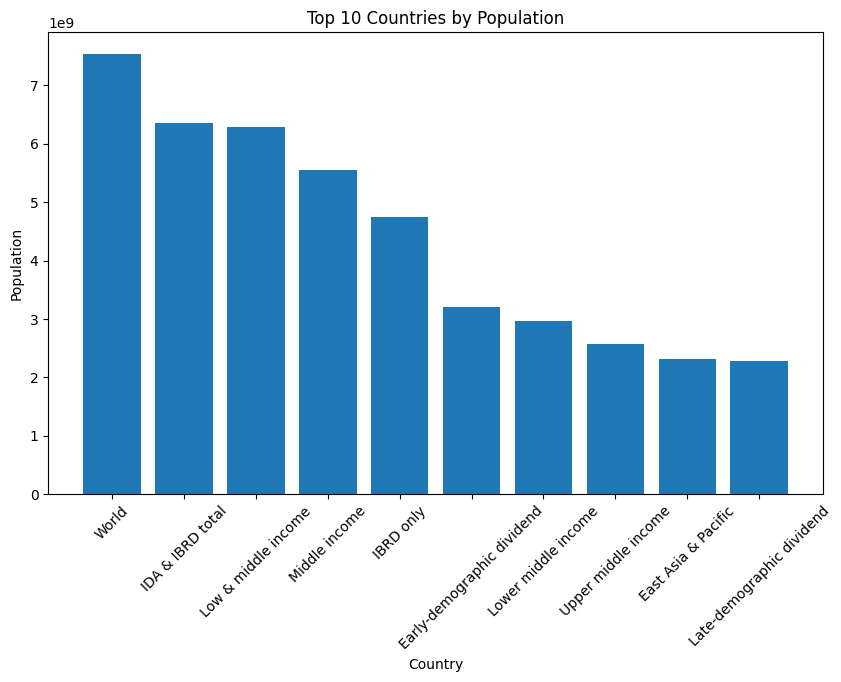

In [31]:
plt.figure(figsize=(10,6))
plt.bar(population_data["Country Name"], population_data["Value"])
plt.title("Top 10 Countries by Population")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

In [32]:
gdp_data = latest_data[
    latest_data["Indicator Code"] == "NY.GDP.MKTP.CD"
].sort_values(by="Value", ascending=False).head(10)

gdp_data[["Country Name", "Value"]]

,Country Name,Value
22671,World,8.093477e+13
22511,High income,5.162592e+13
22611,OECD members,4.977792e+13
22626,Post-demographic dividend,4.723943e+13
22521,IDA & IBRD total,3.084214e+13
22566,Low & middle income,2.933541e+13
22596,Middle income,2.875859e+13
22516,IBRD only,2.871501e+13
22461,East Asia & Pacific,2.399490e+13
22666,Upper middle income,2.218174e+13


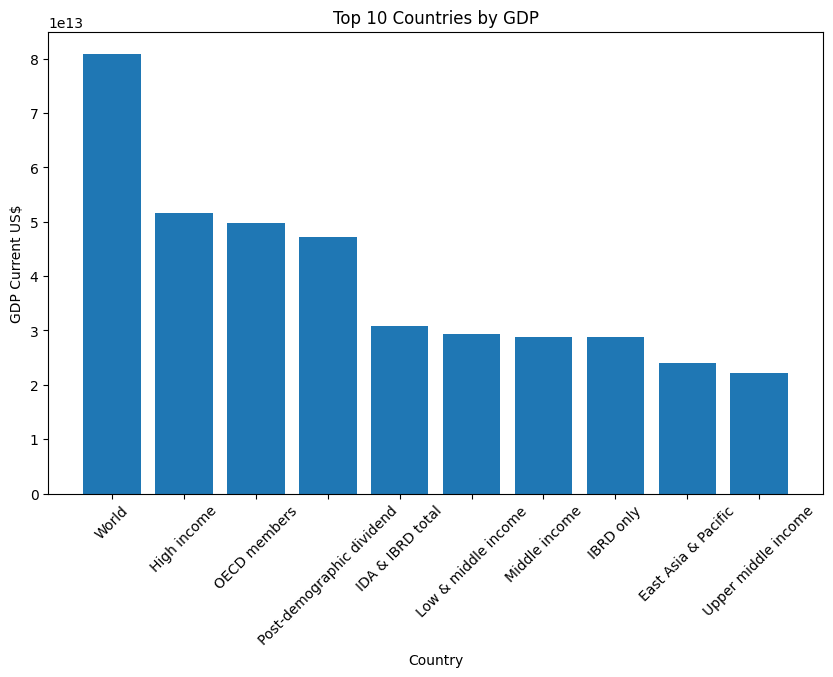

In [33]:
plt.figure(figsize=(10,6))
plt.bar(gdp_data["Country Name"], gdp_data["Value"])
plt.title("Top 10 Countries by GDP")
plt.xlabel("Country")
plt.ylabel("GDP Current US$")
plt.xticks(rotation=45)
plt.show()

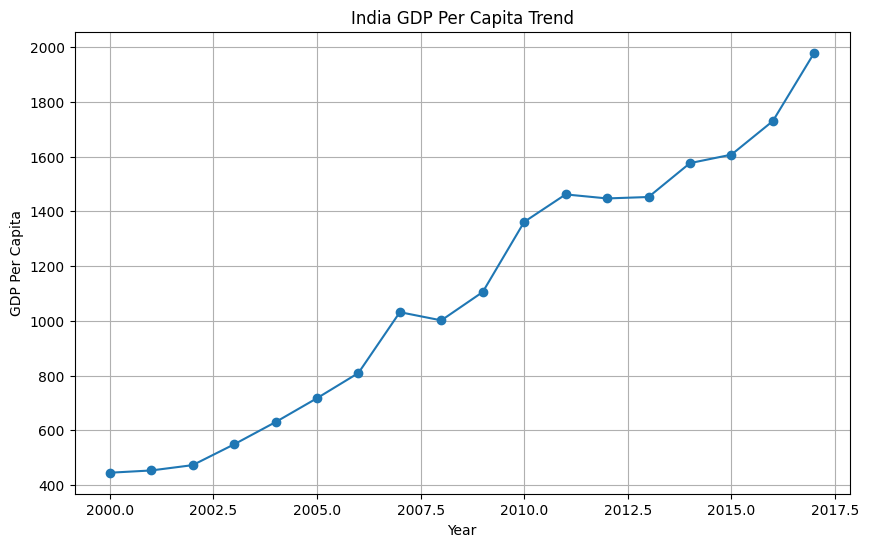

In [34]:
india_gdp = df_long[
    (df_long["Country Name"] == "India") &
    (df_long["Indicator Code"] == "NY.GDP.PCAP.CD")
]

plt.figure(figsize=(10,6))
plt.plot(india_gdp["Year"], india_gdp["Value"], marker="o")
plt.title("India GDP Per Capita Trend")
plt.xlabel("Year")
plt.ylabel("GDP Per Capita")
plt.grid(True)
plt.show()

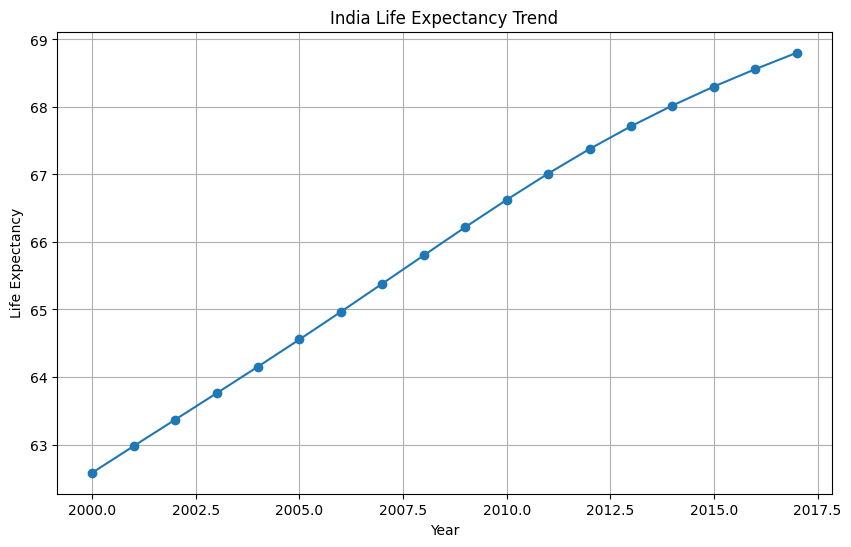

In [35]:
india_life = df_long[
    (df_long["Country Name"] == "India") &
    (df_long["Indicator Code"] == "SP.DYN.LE00.IN")
]

plt.figure(figsize=(10,6))
plt.plot(india_life["Year"], india_life["Value"], marker="o")
plt.title("India Life Expectancy Trend")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()

In [36]:
print("DATASET INSIGHTS")

print("1. The dataset contains country-wise development indicators.")
print("2. Important indicators such as population, GDP, GDP per capita, life expectancy, and electricity access were analyzed.")
print("3. The latest year data was used to identify top countries by population and GDP.")
print("4. India’s GDP per capita shows growth over the selected years.")
print("5. India’s life expectancy also shows improvement over time.")
print("6. Missing values are present because all countries do not report every indicator every year.")
print("7. This analysis helps understand economic, health, and infrastructure development trends.")

DATASET INSIGHTS
1. The dataset contains country-wise development indicators.
2. Important indicators such as population, GDP, GDP per capita, life expectancy, and electricity access were analyzed.
3. The latest year data was used to identify top countries by population and GDP.
4. India’s GDP per capita shows growth over the selected years.
5. India’s life expectancy also shows improvement over time.
6. Missing values are present because all countries do not report every indicator every year.
7. This analysis helps understand economic, health, and infrastructure development trends.
